In [1]:
import os
import glob
import pandas as pd
import numpy as np
import tifffile
import h5py
from tqdm import tqdm
import matplotlib.pyplot as plt
import ast
import re
from datetime import datetime, date
from collections import namedtuple
from itertools import product
from scipy.spatial import distance_matrix
import math
from pathlib import Path


# BELOW IS THE MAIN PREPROCESSING CODE

In [2]:

def get_pinstate(h5_path, mouse, directory):
    # Extract the timestamp from the h5 filename.
    h5_filename = os.path.basename(h5_path)
    m = re.search(r'(\d{4}-\d{2}-\d{2}-\d{6})', h5_filename)
    if not m:
        raise ValueError("No valid timestamp found in the h5 filename.")
    h5_timestamp = datetime.strptime(m.group(1), "%Y-%m-%d-%H%M%S")
    
    # Search for CSV files containing 'pinstate' in the filename in the same directory as the h5 file

    csv_files = [f for f in os.listdir(directory) if f.lower().endswith('.csv') and 'pinstate' in f.lower() and mouse in f]
    
    nearest_filename = None
    min_timedelta = None
    
    # First, try to find a csv file with a timestamp later than or equal to h5 timestamp
    for csv_file in csv_files:
        m_csv = re.search(r'(\d{4}-\d{2}-\d{2}-\d{6})', csv_file)
        if not m_csv:
            continue
        csv_timestamp = datetime.strptime(m_csv.group(1), "%Y-%m-%d-%H%M%S")
        diff = csv_timestamp - h5_timestamp
        if diff.total_seconds() >= 0:
            if min_timedelta is None or diff < min_timedelta:
                min_timedelta = diff
                nearest_filename = csv_file

    # Fallback: if no csv is later than the h5 file, choose the one with the smallest absolute difference
    if nearest_filename is None:
        for csv_file in csv_files:
            m_csv = re.search(r'(\d{4}-\d{2}-\d{2}-\d{6})', csv_file)
            if not m_csv:
                continue
            csv_timestamp = datetime.strptime(m_csv.group(1), "%Y-%m-%d-%H%M%S")
            diff = abs(csv_timestamp - h5_timestamp)
            if min_timedelta is None or diff < min_timedelta:
                min_timedelta = diff
                nearest_filename = csv_file

    if nearest_filename is not None:
        return os.path.join(directory, nearest_filename)
    else:
        return None



def get_pinstate_indices(pinstate_series, min_length=3):

    # Convert to a numpy array if necessary.
    arr = pinstate_series.values if hasattr(pinstate_series, 'values') else pinstate_series
    # Create a Boolean mask for high values.
    high_mask = (arr == max(arr))
    indices = []
    for i in range(len(arr)):
        # Check if this is a transition: current is high and either it's the very first element
        # or the previous state was low.
        if high_mask[i] and (i == 0 or not high_mask[i-1]):
            # Ensure that there are enough data points and that the next (min_length-1) values are high.
            if i + min_length - 1 < len(arr) and np.all(high_mask[i:i+min_length]):
                indices.append(i)
    return np.array(indices)

def extract_task(variables, index=0):
    bracket_part = re.search(r'\[.*\]', variables[index]).group(0)
    return ast.literal_eval(bracket_part)

def get_sorted_h5_files(mouse, folder):
    return sorted(
        [i for i in os.listdir(folder) if mouse in i and '.h5' in i],
        key=lambda fname: datetime.strptime(
            re.search(r'(\d{4}-\d{2}-\d{2}-\d{6})', fname).group(1),
            "%Y-%m-%d-%H%M%S"
        )
    )

def get_nearest_txt_timestamp(h5_path, mouse, directory):
    # Extract the timestamp from the h5 filename
    h5_filename = os.path.basename(h5_path)
    m = re.search(r'(\d{4}-\d{2}-\d{2}-\d{6})', h5_filename)
    if not m:
        raise ValueError("No valid timestamp found in the h5 filename.")
    h5_timestamp = datetime.strptime(m.group(1), "%Y-%m-%d-%H%M%S")
    
    # Get the directory and list all txt files that include the mouse identifier
    if not os.path.isdir(directory):
        raise ValueError(f"Directory {directory} does not exist.")
    
    txt_files = [f for f in os.listdir(directory) if f.lower().endswith('.txt') and mouse in f]
    
    nearest_filename = None
    min_timedelta = None
    
    # Try to find a txt file with a timestamp later than or equal to h5 timestamp
    for txt_file in txt_files:
        m_txt = re.search(r'(\d{4}-\d{2}-\d{2}-\d{6})', txt_file)
        if not m_txt:
            continue
        txt_timestamp = datetime.strptime(m_txt.group(1), "%Y-%m-%d-%H%M%S")
        diff = txt_timestamp - h5_timestamp
        if diff.total_seconds() >= 0:
            if min_timedelta is None or diff < min_timedelta:
                min_timedelta = diff
                nearest_filename = txt_file

    # Fallback: if no txt file is later than the h5 file, choose the one with the smallest absolute difference
    if nearest_filename is None:
        for txt_file in txt_files:
            m_txt = re.search(r'(\d{4}-\d{2}-\d{2}-\d{6})', txt_file)
            if not m_txt:
                continue
            txt_timestamp = datetime.strptime(m_txt.group(1), "%Y-%m-%d-%H%M%S")
            diff = abs(txt_timestamp - h5_timestamp)
            if min_timedelta is None or diff < min_timedelta:
                min_timedelta = diff
                nearest_filename = txt_file

    if nearest_filename is not None:
        return os.path.join(directory, nearest_filename)
    else:
        return None
    



def get_behaviour_txt(Behaviourfile_path, Structure_abstract="ABCD"):
    """
    Retrieves the pycontrol output file for awake sessions and produces a dictionary 
    containing the raw pycontrol data.
    Parameters:
    data_path (str): The base directory path where the data is stored.
    mouse (str): The identifier for the mouse.
    cohort (str): The cohort number or identifier.
    date (str): The date of the session in 'YYYYMMDD' format.
    Behaviour_timestamp (str): The timestamp of the behaviour session.
    Returns:
    dict: A dictionary where keys are event names and values are numpy arrays of event times.
    The function performs the following steps:
    1. Constructs the file path for the behaviour data file.
    2. Reads the file and extracts relevant information.
    3. Parses session information including experiment name, task name, subject ID, and start date.
    4. Extracts state and event IDs, and session data.
    5. Converts subject ID to integer if `int_subject_IDs` is True.
    6. Returns a dictionary with event names as keys and numpy arrays of event times as values.
    Note:
    - The function assumes that the file format and structure are consistent with the expected format.
    """

    

    # print('Importing data file: '+os.path.split(Behaviourfile_path)[1])

    with open(Behaviourfile_path, 'r') as f:
        all_lines = [line.strip() for line in f.readlines() if line.strip()]


    # Extract and store session information.
    file_name = os.path.split(Behaviourfile_path)[1]
    Event = namedtuple('Event', ['time','name'])

    info_lines = [line[2:] for line in all_lines if line[0]=='I']

    experiment_name = next(line for line in info_lines if 'Experiment name' in line).split(' : ')[1]
    task_name       = next(line for line in info_lines if 'Task name'       in line).split(' : ')[1]
    subject_ID_string    = next(line for line in info_lines if 'Subject ID'      in line).split(' : ')[1]
    datetime_string      = next(line for line in info_lines if 'Start date'      in line).split(' : ')[1]



    datetime_ = datetime.strptime(datetime_string, '%Y/%m/%d %H:%M:%S')
    datetime_string = datetime_.strftime('%Y-%m-%d %H:%M:%S')

    # Extract and store session data.

    state_IDs = eval(next(line for line in all_lines if line[0]=='S')[2:])
    event_IDs = eval(next(line for line in all_lines if line[0]=='E')[2:])
    variable_lines = [line[2:] for line in all_lines if line[0]=='V']

    if Structure_abstract not in ['ABCD','AB','ABCDA2','ABCDE','ABCAD']:
        pass
    else:
        structurexx = next(line for line in variable_lines if 'active_poke' in line).split(' active_poke ')[1]
        if 'ot' in structurexx:
            structurex=structurexx[:8]+']'
        else:
            structurex=structurexx

        if Structure_abstract in ['ABCD','AB','ABCDE']:
            structure=np.asarray((structurex[1:-1]).split(',')).astype(int)
        else:
            structure=structurex

        ID2name = {v: k for k, v in {**state_IDs, **event_IDs}.items()}
        data_lines = [line[2:].split(' ') for line in all_lines if line[0]=='D']
        events = [Event(int(dl[0]), ID2name[int(dl[1])]) for dl in data_lines]
        times = {event_name: np.array([ev.time for ev in events if ev.name == event_name])  
                    for event_name in ID2name.values()}
  
    return times, variable_lines


def load_masks_from_directory(mask_dir):
    """
    Load all TIFF binary mask images from a directory.
    Returns a dictionary: subcomponent_name -> 2D boolean numpy array.
    """
    mask_dict = {}
    tiff_files = glob.glob(os.path.join(mask_dir, "*.tif*"))

    for tiff_path in tiff_files:
        filename = os.path.basename(tiff_path)
        # Remove file extension to get subcomponent label (e.g. "node_1" from "node_1.tif")
        subcomponent_name, _ = os.path.splitext(filename)
        
        # Read the binary mask as a 2D numpy array
        mask_array = tifffile.imread(tiff_path)
        
        # Ensure it's boolean
        mask_array = mask_array.astype(bool)
        
        mask_dict[subcomponent_name] = mask_array
    
    return mask_dict


def detect_outliers_by_jump(df, bodypart_names, x_suffix, y_suffix,
                            distance_threshold=None,
                            robust=True, multiplier=3.0):
    """
    Mark body-part positions as NaN if the frame-to-frame jump
    exceeds a distance threshold.
    
    If distance_threshold is None, it is computed from the distribution
    of all distances using either:
      - median + multiplier * MAD (if robust=True), or
      - mean + multiplier * std  (if robust=False).
    """
    df_out = df.copy()

    for bp in bodypart_names:
        x_col = f"{bp}{x_suffix}"
        y_col = f"{bp}{y_suffix}"

        # Skip if columns don't exist
        if x_col not in df_out.columns or y_col not in df_out.columns:
            continue
        
        x_vals = df_out[x_col].values
        y_vals = df_out[y_col].values

        # Calculate frame-to-frame distances
        dx = np.diff(x_vals)
        dy = np.diff(y_vals)
        dist = np.sqrt(dx**2 + dy**2)
        
        # If no threshold provided, auto-compute from the data
        if distance_threshold is None:
            dist_no_nan = dist[~np.isnan(dist)]
            if len(dist_no_nan) == 0:
                # No valid distances, skip
                continue

            if robust:
                # Use median + multiplier * MAD
                median_dist = np.median(dist_no_nan)
                mad = np.median(np.abs(dist_no_nan - median_dist))
                if mad == 0:
                    distance_threshold = median_dist * multiplier
                else:
                    distance_threshold = median_dist + multiplier * mad
            else:
                # mean + multiplier * std
                mean_dist = np.mean(dist_no_nan)
                std_dist = np.std(dist_no_nan)
                distance_threshold = mean_dist + multiplier * std_dist

        # dist[i] is jump from frame i to i+1
        outlier_indices = np.where(dist > distance_threshold)[0] + 1
        # Mark outliers as NaN in the 'destination' frame
        x_vals[outlier_indices] = np.nan
        y_vals[outlier_indices] = np.nan

        df_out[x_col] = x_vals
        df_out[y_col] = y_vals
    
    return df_out


def interpolate_and_smooth_coordinates(df, bodypart_names, x_suffix, y_suffix,
                                       interpolation_method='linear', 
                                       rolling_window=5):
    """
    1) Interpolates NaN values (default 'linear').
    2) Applies a rolling average smoothing over a specified window.
    """
    for bp in bodypart_names:
        x_col = f"{bp}{x_suffix}"
        y_col = f"{bp}{y_suffix}"

        # Skip if missing columns
        if x_col not in df.columns or y_col not in df.columns:
            continue

        # Interpolate: fill internal NaNs from neighbors
        df[x_col] = df[x_col].interpolate(method=interpolation_method, limit_direction='both')
        df[y_col] = df[y_col].interpolate(method=interpolation_method, limit_direction='both')

        # Rolling mean smoothing
        df[x_col] = df[x_col].rolling(window=rolling_window, min_periods=1, center=True).mean()
        df[y_col] = df[y_col].rolling(window=rolling_window, min_periods=1, center=True).mean()

    return df


def estimate_affine_transform(pixel_points, physical_points):
    """
    Estimate the 2x2 matrix A and 2x1 vector b that maps:
        [x_phys, y_phys]^T = A [x_pix, y_pix]^T + b
    using a set of corresponding pixel_points and physical_points.

    pixel_points:   Nx2 array of (x_pix, y_pix)
    physical_points: Nx2 array of (x_phys, y_phys)
    Returns:
        A (2x2 numpy array), b (2x1 numpy array)
    """
    N = pixel_points.shape[0]

    # Build the design matrix M (2N x 6) and vector v (2N x 1).
    # The unknown parameters are [a11, a12, bx, a21, a22, by].
    M = np.zeros((2*N, 6))      
    v = np.zeros((2*N,))

    for i in range(N):
        x_pix, y_pix = pixel_points[i]
        x_phys, y_phys = physical_points[i]

        # x_phys = a11*x_pix + a12*y_pix + bx
        M[2*i, 0] = x_pix
        M[2*i, 1] = y_pix
        M[2*i, 2] = 1.0
        v[2*i]     = x_phys

        # y_phys = a21*x_pix + a22*y_pix + by
        M[2*i+1, 3] = x_pix
        M[2*i+1, 4] = y_pix
        M[2*i+1, 5] = 1.0
        v[2*i+1]    = y_phys

    # Solve in a least squares sense
    solution, residuals, rank, s = np.linalg.lstsq(M, v, rcond=None)
    a11, a12, bx, a21, a22, by = solution

    A = np.array([[a11, a12],
                  [a21, a22]])
    b = np.array([bx, by])

    return A, b

def transform_points(pixel_points, A, b):
    """
    Transform an Nx2 array of pixel_points via the affine transform:
      [x_phys, y_phys]^T = A [x_pix, y_pix]^T + b
    """
    pixel_points = np.asarray(pixel_points)            # shape (N, 2)
    transformed = (A @ pixel_points.T).T + b           # shape (N, 2)
    return transformed


def transform_sleap_dataframe_inplace(df, A, b):
    """
    For each body-part column pair that looks like <part>.x, <part>.y
    in DataFrame df, transform those pixel coordinates in-place to physical (cm).
    i.e., we overwrite the .x, .y columns with the new values.
    
    df: Pandas DataFrame with columns like 'nose.x', 'nose.y', ...
    A, b: affine transform parameters
    """
    # Find all columns ending with ".x".
    x_cols = [col for col in df.columns if col.endswith('.x')]
    
    for x_col in x_cols:
        # Replace '.x' with '.y' to get the matching y column
        y_col = x_col[:-2] + '.y'
        if y_col not in df.columns:
            # If the matching .y doesn't exist, skip
            continue
        
        # Extract Nx2 array of pixel coordinates
        pixel_coords = df[[x_col, y_col]].values
        
        # Transform
        phys_coords = transform_points(pixel_coords, A, b)
        
        # Overwrite the DataFrame columns in-place
        df[x_col] = phys_coords[:, 0]
        df[y_col] = phys_coords[:, 1]
    
    # Return df (not strictly necessary if we modify in-place)
    return df

def compute_head_directions(df, x_suffix=".x", y_suffix=".y"):
    """
    Given a DataFrame that has at least these columns:
        head_mid.x, head_mid.y,
        head_back.x, head_back.y,
        ear_L.x,    ear_L.y,
        ear_R.x,    ear_R.y
    compute two angles per frame:
      - back2mid_deg:  angle from head_back -> head_mid
      - earL2earR_deg: angle from ear_L -> ear_R
    Angles are in degrees, relative to the x-axis, using arctan2 (i.e. [-180, 180] range).

    Returns a new DataFrame of shape (n_frames, 2).
    """
    angles_df = pd.DataFrame(index=df.index, columns=["back2mid_deg", "earL2earR_deg"], dtype=float)

    def angle_deg(x1, y1, x2, y2):
        return np.degrees(np.arctan2(y2 - y1, x2 - x1))

    for i in df.index:
        # Extract the relevant coordinates
        # We do a quick check for any NaNs
        needed_cols = ["head_mid", "head_back", "ear_L", "ear_R"]
        coords = {}
        is_nan = False
        for part in needed_cols:
            xcol = f"{part}{x_suffix}"
            ycol = f"{part}{y_suffix}"
            if (xcol not in df.columns) or (ycol not in df.columns):
                is_nan = True
            else:
                if pd.isna(df.loc[i, xcol]) or pd.isna(df.loc[i, ycol]):
                    is_nan = True
            coords[part] = (df.loc[i, xcol], df.loc[i, ycol])

        if is_nan:
            angles_df.loc[i, ["back2mid_deg", "earL2earR_deg"]] = np.nan
        else:
            (xb, yb) = coords["head_back"]
            (xm, ym) = coords["head_mid"]
            (xl, yl) = coords["ear_L"]
            (xr, yr) = coords["ear_R"]

            # Angle from back -> mid
            back2mid = angle_deg(xb, yb, xm, ym)
            # Angle from left ear -> right ear
            earL2earR = angle_deg(xl, yl, xr, yr)

            angles_df.loc[i, "back2mid_deg"] = back2mid
            angles_df.loc[i, "earL2earR_deg"] = earL2earR

    return angles_df


def map_body_parts_to_subcomponent_h5(
    sleap_h5_path,
    mask_dir,
    output_csv_path,
    # Additional outputs
    cleaned_coords_csv_path="cleaned_coordinates.csv",
    head_direction_csv_path="head_direction.csv",
    # Bodypart parsing
    bodypart_names=None,
    x_suffix=".x",
    y_suffix=".y",
    # Outlier detection params
    outlier_detection=True,
    distance_threshold=None,
    robust=True,
    multiplier=3.0,
    transform_to_physical=False,
    pixel_pts=None,
    physical_pts=None,
    # Interpolation/smoothing params
    interpolation_method='linear',
    rolling_window=5
):
    """
    1) Load SLEAP h5
    2) Optionally do outlier detection
    3) Interpolate + smooth
    4) Save cleaned coordinates to CSV
    5) Compute head direction from (head_mid, head_back, ear_L, ear_R), save to CSV
    6) Load masks
    7) Map each body-part coordinate to subcomponent, save final mapping

    Args:
        sleap_csv_path: path to the original SLEAP CSV
        mask_dir: directory containing the binary mask TIFF files
        output_csv_path: path for final subcomponent membership CSV
        cleaned_coords_csv_path: path for saving the post-processed (x,y) CSV
        head_direction_csv_path: path for saving the head orientation CSV
        bodypart_names: if None, infer from columns. Otherwise, list of bodypart strings
        x_suffix, y_suffix: how the SLEAP CSV columns are named (default ".x"/".y")
        outlier_detection: whether to remove large jumps
        distance_threshold: pixel threshold for outliers (or None to auto-calc)
        robust: if True and threshold is None, use median+MAD; else mean+std
        multiplier: factor for outlier detection
        interpolation_method: method for pd.DataFrame.interpolate (e.g. 'linear')
        rolling_window: window size for rolling-average smoothing
    """
    # 1) Load SLEAP CSV

        # 1. Load SLEAP HDF5
        # 1. Load SLEAP HDF5

    # with h5py.File(sleap_h5_path, 'r') as f:
    #     tracks = f['tracks'][:]

    #     ##############
    #     bodypart_names = [name if isinstance(name, str) else name.decode('utf-8') for name in list(f['node_names'][:])]
    #     print("Bodypart names:", bodypart_names)
        
    #     data = {name: f['tracks'][:, :, i] for i, name in enumerate(bodypart_names)}
    #     print(data['head_mid'].shape)
    #     sleap_df = pd.DataFrame(data)

    with h5py.File(sleap_h5_path, 'r') as f:
        tracks = f['tracks'][:]
        print("Tracks shape:", tracks.shape)  # (tracks, n_frames, n_bodyparts, 2)

        tracks = np.nanmean(tracks, axis=0)[np.newaxis, :, :, :]  # Take median across videos, keep shape (1, n_frames, n_bodyparts, 2)


        bodypart_names = bodypart_names or list(f['node_names'][:])


        ##############
        bodypart_names_h5 = [name if isinstance(name, str) else name.decode('utf-8') for name in list(f['node_names'][:])]
        
        if len(bodypart_names) == 1:
            # Find the index in f['node_names'] where the bodypart name appears

            bodypart_ind = np.where(np.array(bodypart_names_h5) == bodypart_names[0])[0][0]
            
            data = {bodypart_names_h5[0]: tracks[0, :, bodypart_ind, :]}
            
            data_dict = {}
            data_dict[f"{bodypart_names[0]}{x_suffix}"] = tracks[0, 0, bodypart_ind, :]
            data_dict[f"{bodypart_names[0]}{y_suffix}"] = tracks[0, 1, bodypart_ind, :]
        else:
            data = {name: tracks[0, :, i, :] for i, name in enumerate(bodypart_names_h5)}
            data_dict = {}
            for i, bp in enumerate(bodypart_names_h5):
                data_dict[f"{bp}{x_suffix}"] = tracks[0, 0, i, :]
                data_dict[f"{bp}{y_suffix}"] = tracks[0, 1, i, :]
 
        sleap_df = pd.DataFrame(data_dict)
    
    sleap_df_formasks = sleap_df.copy()
    # print(sleap_df_formasks)
    # 2) Identify bodypart names
    # if bodypart_names is None:
    #     x_cols = [col for col in sleap_df.columns if col.endswith(x_suffix)]
    #     bodypart_names = [col.replace(x_suffix, "") for col in x_cols]

    # 3) Outlier detection (optional)
    if outlier_detection:
        sleap_df = detect_outliers_by_jump(
            sleap_df, 
            bodypart_names,
            x_suffix,
            y_suffix,
            distance_threshold=distance_threshold,
            robust=robust,
            multiplier=multiplier
        )

    # 4) Interpolate and smooth
    sleap_df = interpolate_and_smooth_coordinates(
        sleap_df,
        bodypart_names,
        x_suffix,
        y_suffix,
        interpolation_method=interpolation_method,
        rolling_window=rolling_window
    )

    # 5 compute affine transform to put into physical coordinates
    if transform_to_physical:
        A, b = estimate_affine_transform(pixel_pts, physical_pts)
        print("Estimated affine matrix A:\n", A)
        print("Estimated translation vector b:\n", b)
        sleap_df = transform_sleap_dataframe_inplace(sleap_df, A, b)

    # ---- (A) SAVE the cleaned coordinates to CSV
    sleap_df.to_csv(cleaned_coords_csv_path, index=False)
    print(f"Cleaned coordinates saved to: {cleaned_coords_csv_path}")

    # 5) Compute head direction angles from head_mid, head_back, ear_L, ear_R
    head_directions_df = compute_head_directions(sleap_df, x_suffix, y_suffix)
    # Save to CSV
    head_directions_df.to_csv(head_direction_csv_path, index=False)
    print(f"Head direction angles saved to: {head_direction_csv_path}")

    # 6) Load the binary mask TIFFs
    masks = load_masks_from_directory(mask_dir)
    # We assume all masks share the same shape
    mask_shape = None
    if len(masks) > 0:
        key = next(iter(masks.keys()))
        mask_shape = masks[key].shape

    # 7) Map each coordinate to subcomponent
    out_subcomp_df = pd.DataFrame(index=sleap_df_formasks.index, columns=bodypart_names_h5, dtype=object)
    for i, row_data in sleap_df_formasks.iterrows():
        for bp in bodypart_names_h5:
            x_col = f"{bp}{x_suffix}"
            y_col = f"{bp}{y_suffix}"

            if x_col not in sleap_df_formasks.columns or y_col not in sleap_df_formasks.columns:
                out_subcomp_df.at[i, bp] = "None"
                continue

            x_coord = row_data[x_col]
            y_coord = row_data[y_col]

            # If still NaN, label as "None"
            if pd.isna(x_coord) or pd.isna(y_coord):
                out_subcomp_df.at[i, bp] = "None"
                continue
            
            x_idx = int(round(x_coord))
            y_idx = int(round(y_coord))

            # Check if out of bounds
            if mask_shape is not None:
                h, w = mask_shape
                if x_idx < 0 or x_idx >= w or y_idx < 0 or y_idx >= h:
                    out_subcomp_df.at[i, bp] = "None"
                    continue

            # Identify which mask is True
            found_subcomponent = False
            for subcomp_name, mask_arr in masks.items():
                if mask_arr[y_idx, x_idx]:
                    out_subcomp_df.at[i, bp] = subcomp_name
                    found_subcomponent = True
                    break
            if not found_subcomponent:
                out_subcomp_df.at[i, bp] = "None"

    # 8) Save final subcomponent membership
    out_subcomp_df.to_csv(output_csv_path, index=False)
    print(f"Subcomponent mapping saved to: {output_csv_path}")

def get_date_from_filename(filename):
    """
    Extracts a date object from a filename string that contains a date
    in YYYY-MM-DD format.
    Example: "..._2024-03-25-123456..." -> datetime.date(2024, 3, 25)
    Returns None if no date is found.
    """
    match = re.search(r'(\d{4}-\d{2}-\d{2})', filename)
    if match:
        date_str = match.group(1)
        return datetime.strptime(date_str, '%Y-%m-%d').date()
    return None



def get_mouse_locations(trial_times_array, ROIs_int):
    """
    Given a trial times array and a list of ROIs_int, returns an array of the same structure
    but where the entries are the mouse's location at each of the time bins.
    
    Parameters:
    -----------
    trial_times_array : np.ndarray
        Array of trial times.
    ROIs_int : list
        List of mouse locations (ROIs) as integers.
    
    Returns:
    --------
    np.ndarray
        Array of the same structure as trial_times_array but with mouse locations.
    """
    n_trials, n_states = trial_times_array.shape
    mouse_locations = np.zeros_like(trial_times_array, dtype=int)
    
    for i in range(n_trials):
        for j in range(n_states):
            time_bin = int(trial_times_array[i, j])
            if time_bin < len(ROIs_int):
                if np.isnan(ROIs_int[time_bin]):
                    mouse_locations[i, j] = 999
                else:
                    mouse_locations[i, j] = ROIs_int[time_bin]
            else:
                mouse_locations[i, j] = np.nan  # Handle out-of-bounds case
    
    return mouse_locations
 







In [3]:

# Class for converting timestamps between recording systems using sync pulses with
# random inter-pulse intervals.
# https://pycontrol.readthedocs.io/en/latest/user-guide/synchronisation
# Dependencies:  Python 3, Numpy, Matplotlib, Scikit-learn.
# (c) Thomas Akam 2018-2023. Released under the GPL-3 open source licence.

import numpy as np
import pylab as plt
from sklearn.mixture import GaussianMixture


class RsyncError(Exception):
    pass


class Rsync_aligner:
    def __init__(
        self,
        pulse_times_A,
        pulse_times_B,
        units_A="auto",
        units_B="auto",
        chunk_size=5,
        plot=False,
        raise_exception=True,
    ):
        """Class for converting timestamps between two recording systems
        (e.g  pyControl and an ephys) using sync pulses with random inter-pulse
        intervals recorded on both systems.  Typically these sync pulses are generated
        by pyControl using the Rsync hardware object and sent to other systems. To use the
        Rsync_aligner,instantiate it by providing the sync pulse times recorded by each
        system. Timestamps from either system can then be converted into the reference frame
        of the other using the A_to_B and B_to_A methods.  If the hardware systems use
        different units to measure time this can either be specified manually using the units
        arguments when the aligner is instantiated, or estimated automatically by setting
        the units arguments to 'auto'. When the aligner is instantiated it works out
        which pulses in each reference frame correspond to each other by by aligning
        short chunks of pulse sequence A with B by minimising the mean squared error
        between inter-pulse intervals.

        Arguments:

        pulse_times_A: The times when sync pulses occured recorded by hardware system A.

        pulse_times_B: The times when sync pulses occured recorded by hardware system B.

        units_A: The time units used by system A expressed in milliseconds.  E.g. if
                 system A uses units of seconds the *units_A* argument is 1000. If either
                 of the units_A or units_B arguments is set to 'auto' the units of B
                 relative to A are estimated automatically.

        units_B: The time units used by system B expressed in milliseconds.

        plot: Whether to plot information about the alignment.

        raise_exception: If *True* an RsyncError exception is raised if no match is found
                         between the sync pulse sequences.

        """
        if units_A == "auto" or units_B == "auto":
            # Estimate the units of B relative to A automatically.
            raw_intervals_A = np.diff(pulse_times_A)
            raw_intervals_B = np.diff(pulse_times_B)
            # Exclude very long intervals as likely due to missing pulses.
            good_intervals_A = raw_intervals_A[raw_intervals_A < 3 * np.median(raw_intervals_A)]
            good_intervals_B = raw_intervals_B[raw_intervals_B < 3 * np.median(raw_intervals_B)]
            # Estimate units of B relative to A using the mean of the good intervals.
            units_A = 1
            units_B = np.mean(good_intervals_A) / np.mean(good_intervals_B)
        # Evalute inter-pulse intervals in common units.
        intervals_A = np.diff(pulse_times_A) * units_A  # Inter-pulse intervals for sequence A
        intervals_B = np.diff(pulse_times_B) * units_B  # Inter-pulse intervals for sequence B
        intervals_B2 = intervals_B**2
        # Find alignments of chunks which minimise sum of squared errors.
        chunk_starts_A = np.arange(
            0, len(pulse_times_A) - chunk_size, chunk_size
        )  # Start indices of each chunk of sequence A.
        chunk_starts_B = np.zeros(chunk_starts_A.shape, int)  # Start indicies of corresponding chunks in B.
        chunk_min_mse = np.zeros(chunk_starts_A.shape)  # Mean squared error for each chunks best alignment.
        chunk_2nd_mse = np.zeros(chunk_starts_A.shape)  # Mean sqared error for each chunks 2nd best alignment.
        ones_chunk = np.ones(chunk_size)
        for i, csA in enumerate(chunk_starts_A):
            chunk_A = intervals_A[csA : csA + chunk_size]
            mse = (
                np.correlate(intervals_B2, ones_chunk, mode="valid")
                + np.sum(chunk_A**2)
                - 2 * np.correlate(intervals_B, chunk_A, mode="valid")
            ) / chunk_size
            chunk_starts_B[i] = np.argmin(mse)
            sorted_chunk_min_mse = np.sort(mse)
            chunk_min_mse[i] = sorted_chunk_min_mse[0]
            chunk_2nd_mse[i] = sorted_chunk_min_mse[1]
        # Assign chunks to matched and non-matched groups by fitting 2 component Gaussian mixture model
        # to log mse distribition of best + second best alignments.
        chunk_mse = np.hstack([chunk_min_mse, chunk_2nd_mse])
        chunk_mse[chunk_mse == 0] = np.min(chunk_mse[chunk_mse != 0])  # Replace zeros with smallest non zero value.
        log_mse = np.log(chunk_mse)
        log_mse = log_mse[np.isfinite(log_mse)].reshape(-1, 1)
        gmm = GaussianMixture(n_components=2, covariance_type="spherical")
        gmm.fit(log_mse)
        valid_matches = gmm.predict(log_mse) == np.argmin(gmm.means_)  # True for chunks which are valid matches.
        # Make arrays of corresponding times.
        cor_times_A = np.full(pulse_times_B.shape, np.nan)  # A pulse times corresponding to each B pulse.
        cor_times_B = np.full(pulse_times_A.shape, np.nan)  # B pulse times corresponding to each A pulse.
        for csA, csB, valid in zip(chunk_starts_A, chunk_starts_B, valid_matches):
            if valid:
                cor_times_A[csB : csB + chunk_size] = pulse_times_A[csA : csA + chunk_size]
                cor_times_B[csA : csA + chunk_size] = pulse_times_B[csB : csB + chunk_size]
        # Store pulse times, their correspondences and units.
        self.pulse_times_A = pulse_times_A
        self.pulse_times_B = pulse_times_B
        self.cor_times_A = cor_times_A
        self.cor_times_B = cor_times_B
        self.units_A = units_A
        self.units_B = units_B
        # Compute variables used for extrapolating beyond first/last matching pulse.
        diff_cor_times_B = np.diff(cor_times_B)
        self.dAdB = np.sum(np.diff(pulse_times_A)[~np.isnan(diff_cor_times_B)]) / np.sum(
            diff_cor_times_B[~np.isnan(diff_cor_times_B)]
        )  # Empirical units_A/units_B from matched inter-pulse intervals.
        matched_pulse_times_A = cor_times_A[~np.isnan(cor_times_A)]
        matched_pulse_times_B = cor_times_B[~np.isnan(cor_times_B)]
        self.first_matched_time_A = matched_pulse_times_A[0]
        self.last_matched_time_A = matched_pulse_times_A[-1]
        self.first_matched_time_B = matched_pulse_times_B[0]
        self.last_matched_time_B = matched_pulse_times_B[-1]
        # Check quality of alignment.
        separation_OK = np.abs(gmm.means_[0] - gmm.means_[1])[0] > 3 * np.sum(
            np.sqrt(gmm.covariances_)
        )  # Difference in GMM means > 3 x sum of standard deviations.
        order_OK = (np.nanmin(np.diff(cor_times_A)) > 0) and (
            np.nanmin(np.diff(cor_times_A)) > 0
        )  # Corresponding times are monotonically increacing.
        if not (separation_OK and order_OK):
            if raise_exception:
                raise RsyncError("No match found between inter-pulse interval sequences.")
            else:
                print("Rsync warning: No match found between inter-pulse interval sequences.")
        # Plotting
        if plot:
            plt.figure(plot if isinstance(plot, int) else 1, figsize=[7, 9]).clf()
            plt.subplot2grid((3, 3), (0, 0), rowspan=1, colspan=2)
            plt.hist(log_mse[valid_matches], 20, color="b", label="Match")
            plt.hist(log_mse[~valid_matches], 20, color="r", label="Non-match")
            plt.legend(loc="upper center")
            plt.xlabel("Log mean squared error")
            plt.ylabel("# chunks")
            plt.subplot2grid((3, 3), (0, 2), rowspan=1, colspan=1)
            timing_errors = np.diff(cor_times_A) - np.diff(pulse_times_B)
            plt.hist(timing_errors[~np.isnan(timing_errors)], 100)
            plt.yscale("log", nonpositive="clip")
            plt.xlabel("Inter-pulse interval\ndiscrepancy (ms)")
            plt.ylabel("# pulses")
            plt.subplot2grid((3, 1), (1, 0), rowspan=2, colspan=1)
            plt.plot(pulse_times_A, cor_times_B, ".", markersize=2)
            plt.xlim(pulse_times_A[0], pulse_times_A[-1])
            plt.xlabel("pulse times A")
            plt.ylabel("pulse times B")
            plt.tight_layout()

    def A_to_B(self, times_A, extrapolate=True):
        """Convert times in A reference frame to B reference frame.  If extrapolate=True, times
        before the first matched sync pulse and after the last matched sync pulse will be
        extrapolated, if False they will be nans.
        """
        times_B = np.interp(times_A, self.pulse_times_A, self.cor_times_B, left=np.nan, right=np.nan)
        if extrapolate:
            pf = times_A < self.first_matched_time_A  # Mask indicating times pre first matched pulse.
            times_B[pf] = (times_A[pf] - self.first_matched_time_A) / self.dAdB + self.first_matched_time_B
            pl = times_A > self.last_matched_time_A  # Mask indicating times post last matched pulse.
            times_B[pl] = (times_A[pl] - self.last_matched_time_A) / self.dAdB + self.last_matched_time_B
        return times_B

    def B_to_A(self, times_B, extrapolate=True):
        """Convert times in B reference frame to A reference frame. If extrapolate=True, times
        before the first matched sync pulse and after the last matched sync pulse will be
        extrapolated, if False they will be nans.
        """
        times_A = np.interp(times_B, self.pulse_times_B, self.cor_times_A, left=np.nan, right=np.nan)
        if extrapolate:
            pf = times_B < self.first_matched_time_B  # Mask indicating times pre first matched pulse.
            times_A[pf] = (times_B[pf] - self.first_matched_time_B) * self.dAdB + self.first_matched_time_A
            pl = times_B > self.last_matched_time_B  # Mask indicating times post last matched pulse.
            times_A[pl] = (times_B[pl] - self.last_matched_time_B) * self.dAdB + self.last_matched_time_A
        return times_A


# --------------------------------------------------------------------------


def simulate_pulses(n_pulse=1000, interval=[100, 1900], units_B=2, noise_SD=2, missing_pulses=False):
    """Simulate a pair of pulse trains timestamps with drift between their timings."""
    pulse_times_A = np.cumsum(np.random.randint(*interval, size=n_pulse)).astype(float)
    pulse_times_B = units_B * (pulse_times_A + np.cumsum(np.random.normal(scale=noise_SD, size=n_pulse)))
    if missing_pulses:
        pulse_times_A = np.hstack(
            [
                pulse_times_A[int(n_pulse * 0.05) : int(n_pulse * 0.21)],
                pulse_times_A[int(n_pulse * 0.33) :] + 2e5,
            ]
        )
        pulse_times_B = np.hstack(
            [
                pulse_times_B[: int(n_pulse * 0.74)],
                pulse_times_B[int(n_pulse * 0.85) : int(n_pulse * 0.95)],
            ]
        )
    return pulse_times_A, pulse_times_B


In [4]:
mouse_pairs = [
    ('ah10', '-'),
    ('ah08', 'ly07'),
    ('ly05', 'ly06')
]
os.chdir('/ceph/behrens/adam_harris/Taskspace_abstraction_lEC')

pinstate_dir = 'data/raw/pinstate'
pycontrol_dir = 'data/raw/pycontrol'
sleap_dir = 'data/raw/sleap'

for mouse in os.listdir(sleap_dir):
    sleap_dir_mouse = f"{sleap_dir}/{mouse}/maze"
    sleap_files = get_sorted_h5_files(mouse, sleap_dir_mouse)
    for sleap_file in sleap_files:
        sleap_file_path = f"{sleap_dir_mouse}/{sleap_file}" 
        print(f"Processing SLEAP file: {sleap_file_path}")
        pinstate_csv = get_pinstate(sleap_file_path, mouse, pinstate_dir)
        pycontrol_txt = get_nearest_txt_timestamp(sleap_file_path, mouse, pycontrol_dir)

        if pinstate_csv and pycontrol_txt:
            print(f"Found Pinstate file: {os.path.basename(pinstate_csv)}")
            print(f"Found Pycontrol file: {os.path.basename(pycontrol_txt)}")

            behaviour_timestamps, variables = get_behaviour_txt(pycontrol_txt)
            task = extract_task(variables)
            pinstate = pd.read_csv(pinstate_csv)
            sync_indices = np.where(pinstate > np.median(pinstate))[0]
            sync_indices = sync_indices[np.diff(np.concatenate(([0], sync_indices))) > 1]        
            print(len(sync_indices), len(behaviour_timestamps['rsync']))
            

            
            # Further processing would go here
        else:
            if not pinstate_csv:
                print("Could not find a matching pinstate file.")
            if not pycontrol_txt:
                print("Could not find a matching pycontrol txt file.")
        print("-" * 20)

        






Processing SLEAP file: data/raw/sleap/ly06/maze/ly06_ly07_implanted.000_ly06_2025-06-04-110307.analysis.h5
Found Pinstate file: ly06_pinstate_2025-06-04-110307.csv
Found Pycontrol file: ly06-2025-06-04-110317.txt
465 241
--------------------
Processing SLEAP file: data/raw/sleap/ly06/maze/ly06_ly07_implanted.001_ly06_2025-06-04-122202.analysis.h5
Found Pinstate file: ly06_pinstate_2025-06-04-122202.csv
Found Pycontrol file: ly06-2025-06-04-122211.txt
484 245
--------------------
Processing SLEAP file: data/raw/sleap/ly06/maze/ly06_ly07_implanted.002_ly06_2025-06-04-133705.analysis.h5
Found Pinstate file: ly06_pinstate_2025-06-04-133705.csv
Found Pycontrol file: ly06-2025-06-04-133713.txt
501 256
--------------------
Processing SLEAP file: data/raw/sleap/ly06/maze/ly06_ly07_implanted.003_ly06_2025-06-04-170606.analysis.h5
Found Pinstate file: ly06_pinstate_2025-06-04-170606.csv
Found Pycontrol file: ly06-2025-06-04-170614.txt
493 255
--------------------
Processing SLEAP file: data/raw/

KeyboardInterrupt: 

--- Checking pair: (ah08, ly07) ---
Found a matched pair with pulses:
  ah08_pinstate_2025-07-15-153759.csv: 508 pulses. First pulse index: 11978
  ly07_pinstate_2025-07-15-153759.csv: 508 pulses. First pulse index: 11986
difference in first pulse indices: 8
----------
Found a matched pair with pulses:
  ah08_pinstate_2025-06-20-134050.csv: 466 pulses. First pulse index: 2051
  ly07_pinstate_2025-06-20-134050.csv: 464 pulses. First pulse index: 2053
difference in first pulse indices: 2
----------
Found a matched pair with pulses:
  ah08_pinstate_2025-07-15-124914.csv: 534 pulses. First pulse index: 1698
  ly07_pinstate_2025-07-15-124914.csv: 533 pulses. First pulse index: 1699
difference in first pulse indices: 1
----------
Found a matched pair with pulses:
  ah08_pinstate_2025-06-20-145922.csv: 470 pulses. First pulse index: 3075
  ly07_pinstate_2025-06-20-145922.csv: 470 pulses. First pulse index: 3076
difference in first pulse indices: 1
----------
Found a matched pair with pulses:


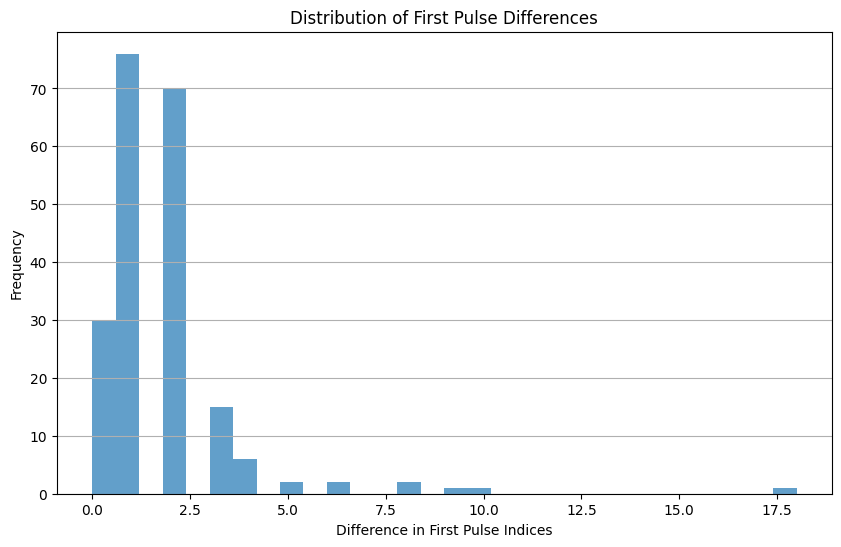

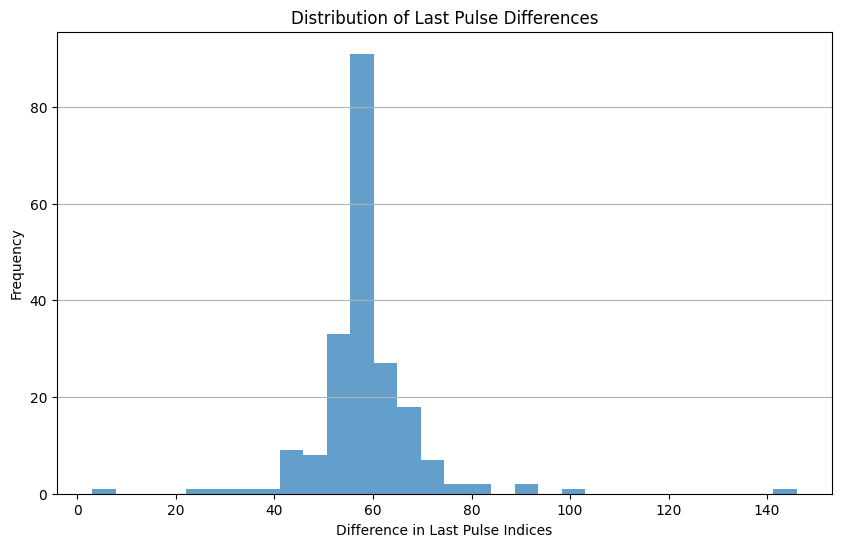

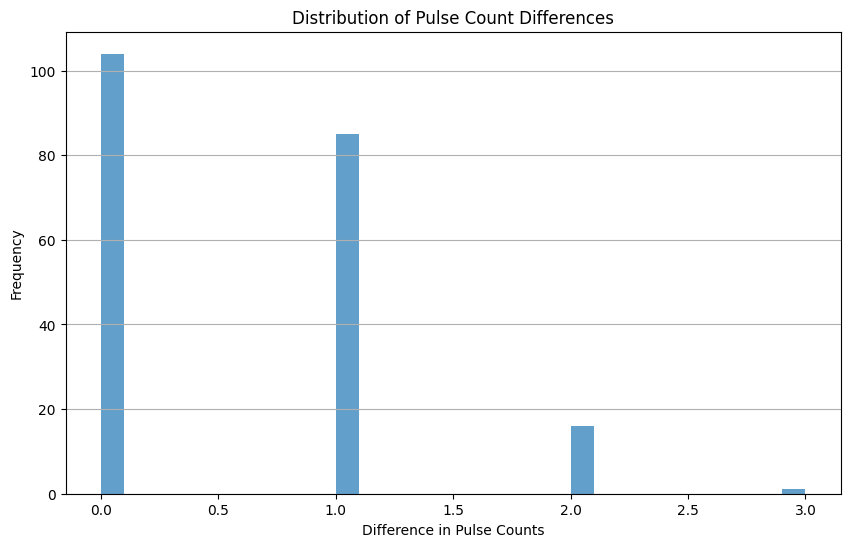

In [7]:
from datetime import timedelta

def count_pinstate_pulses(pinstate_csv_path):
    """Counts the number of rising edges in a pinstate signal."""
    try:
        pinstate = pd.read_csv(pinstate_csv_path)
        # Use the first column if there are multiple
        pinstate_series = pinstate.iloc[:, 0]
        # Find indices where the signal is high (above median)
        high_indices = np.where(pinstate_series > pinstate_series.median())[0]
        if len(high_indices) == 0:
            return 0
        # A pulse is a transition from low to high, so we look for jumps in indices.
        # The diff > 1 logic finds the start of each group of consecutive high indices.
        pulses = high_indices[np.concatenate(([True], np.diff(high_indices) > 1))]
        return len(pulses)
    except Exception as e:
        print(f"Could not process {pinstate_csv_path}: {e}")
        return 0

# Get all pinstate files and parse their info
all_pinstate_files = []
for f in os.listdir(pinstate_dir):
    if f.endswith('.csv') and 'pinstate' in f:
        match = re.search(r'(\d{4}-\d{2}-\d{2}-\d{6})', f)
        if match:
            timestamp = datetime.strptime(match.group(1), "%Y-%m-%d-%H%M%S")
            mouse_id = f.split('_')[0]
            all_pinstate_files.append({'mouse': mouse_id, 'file': f, 'timestamp': timestamp})

# Iterate through mouse pairs to find matching recordings

first_stamp_differences = []
last_stamp_differences = []

difference_number_of_pulses = []
for mouse1, mouse2 in mouse_pairs:
    if mouse2 == '-':
        continue

    print(f"--- Checking pair: ({mouse1}, {mouse2}) ---")
    
    mouse1_files = [f for f in all_pinstate_files if f['mouse'] == mouse1]
    mouse2_files = [f for f in all_pinstate_files if f['mouse'] == mouse2]

    # Find pairs of files with timestamps within 2 seconds of each other
    for f1 in mouse1_files:
        for f2 in mouse2_files:
            if abs(f1['timestamp'] - f2['timestamp']) < timedelta(seconds=2):
                
                # Process mouse1
                path1 = os.path.join(pinstate_dir, f1['file'])
                pinstate1 = pd.read_csv(path1)
                pinstate_series1 = pinstate1.iloc[:, 0]
                high_indices1 = np.where(pinstate_series1 > pinstate_series1.median())[0]
                pulses1 = high_indices1[np.concatenate(([True], np.diff(high_indices1) > 1))] if len(high_indices1) > 0 else np.array([])

                # Process mouse2
                path2 = os.path.join(pinstate_dir, f2['file'])
                pinstate2 = pd.read_csv(path2)
                pinstate_series2 = pinstate2.iloc[:, 0]
                high_indices2 = np.where(pinstate_series2 > pinstate_series2.median())[0]
                pulses2 = high_indices2[np.concatenate(([True], np.diff(high_indices2) > 1))] if len(high_indices2) > 0 else np.array([])

                # Check if both have at least one pulse
                if len(pulses1) > 0 and len(pulses2) > 0:
                    print(f"Found a matched pair with pulses:")
                    first_pulse1 = pulses1[0]
                    print(f"  {f1['file']}: {len(pulses1)} pulses. First pulse index: {first_pulse1}")

                    first_pulse2 = pulses2[0]
                    print(f"  {f2['file']}: {len(pulses2)} pulses. First pulse index: {first_pulse2}")

                    print("difference in first pulse indices:", abs(first_pulse1 - first_pulse2))
                    first_stamp_differences.append(abs(first_pulse1 - first_pulse2))
                    last_pulse1 = pulses1[-1]
                    last_pulse2 = pulses2[-1]
                    last_stamp_differences.append(abs(last_pulse1 - last_pulse2))
                    print("-" * 10)
                    difference_number_of_pulses.append(abs(len(pulses1) - len(pulses2)))
                else:
                    print(f"No valid pulses found for pair: {f1['file']} and {f2['file']}")

import matplotlib.pyplot as plt


plt.figure(figsize=(10, 6))
plt.hist(first_stamp_differences, bins=30, alpha=0.7)
plt.title("Distribution of First Pulse Differences")
plt.xlabel("Difference in First Pulse Indices")
plt.ylabel("Frequency")
plt.grid(axis='y')
plt.show()


plt.figure(figsize=(10, 6))
plt.hist(last_stamp_differences, bins=30, alpha=0.7)
plt.title("Distribution of Last Pulse Differences")
plt.xlabel("Difference in Last Pulse Indices")
plt.ylabel("Frequency")
plt.grid(axis='y')
plt.show()


plt.figure(figsize=(10, 6))
plt.hist(difference_number_of_pulses, bins=30, alpha=0.7)
plt.title("Distribution of Pulse Count Differences")
plt.xlabel("Difference in Pulse Counts")
plt.ylabel("Frequency")
plt.grid(axis='y')
plt.show()


In [63]:
# Find a pair of files with different pulse counts
found_pair = False
for mouse1, mouse2 in mouse_pairs:
    if mouse2 == '-':
        continue

    mouse1_files = [f for f in all_pinstate_files if f['mouse'] == mouse1]
    mouse2_files = [f for f in all_pinstate_files if f['mouse'] == mouse2]

    for f1 in mouse1_files:
        for f2 in mouse2_files:
            if abs(f1['timestamp'] - f2['timestamp']) < timedelta(seconds=2):
                path1_temp = os.path.join(pinstate_dir, f1['file'])
                path2_temp = os.path.join(pinstate_dir, f2['file'])
                
                pulses1_count = count_pinstate_pulses(path1_temp)
                pulses2_count = count_pinstate_pulses(path2_temp)

                if pulses1_count != pulses2_count:
                    path1 = path1_temp
                    path2 = path2_temp
                    print(f"Selected pair with different pulse counts:")
                    print(f"  {os.path.basename(path1)}: {pulses1_count} pulses")
                    print(f"  {os.path.basename(path2)}: {pulses2_count} pulses")
                    found_pair = True
                    break
        if found_pair:
            break
    if found_pair:
        break

if not found_pair:
    print("Could not find a matched pair with a different number of pulses.")
    # As a fallback, use the last matched pair from the previous cell's logic
    # This assumes 'path1' and 'path2' are still in memory from cell 5
    if 'path1' not in locals() or 'path2' not in locals():
         raise NameError("No suitable file pair found and path1/path2 not defined from previous cell.")




def get_pinstate_pulses(pinstate_csv_path):
    """Gets the timestamps (indices) of rising edges in a pinstate signal."""
    try:
        pinstate = pd.read_csv(pinstate_csv_path)
        pinstate_series = pinstate.iloc[:, 0]
        high_indices = np.where(pinstate_series > pinstate_series.median())[0]
        if len(high_indices) == 0:
            return np.array([])
        pulses = high_indices[np.concatenate(([True], np.diff(high_indices) > 1))]
        return pulses
    except Exception as e:
        print(f"Could not process {pinstate_csv_path}: {e}")
        return np.array([])

# Assuming path1 and path2 are defined from the previous cell's matched pair
pulses1 = get_pinstate_pulses(path1)
pulses2 = get_pinstate_pulses(path2)



ephys_aligner = Rsync_aligner(
    pulse_times_A=pulses1,
    pulse_times_B=pulses2,
)

Selected pair with different pulse counts:
  ah08_pinstate_2025-06-20-134050.csv: 466 pulses
  ly07_pinstate_2025-06-20-134050.csv: 464 pulses


In [64]:
pulse_times_A = ephys_aligner.pulse_times_A
pulse_times_B = ephys_aligner.pulse_times_B

In [70]:
pulse_times_A

array([ 2051,  2056,  2271,  2404,  2475,  2481,  2563,  2599,  2750,
        2800,  2901,  3095,  3175,  3490,  3664,  3768,  3987,  4045,
        4113,  4269,  4323,  4497,  4581,  4912,  5028,  5335,  5400,
        5556,  5857,  5934,  6157,  6205,  6306,  6393,  6614,  6846,
        6915,  7056,  7210,  7283,  7666,  7711,  7981,  8100,  8191,
        8494,  8498,  8938,  8982,  9104,  9380,  9417,  9819,  9854,
       10330, 10353, 10386, 10437, 10498, 10902, 10973, 11279, 11440,
       11578, 11824, 11944, 12189, 12228, 12324, 12690, 12758, 13002,
       13239, 13289, 13517, 13768, 13815, 14232, 14373, 14558, 14768,
       14865, 15091, 15381, 15487, 15515, 15795, 15859, 16232, 16262,
       16439, 16633, 16789, 16881, 17114, 17160, 17372, 17689, 17820,
       17938, 18166, 18357, 18456, 18666, 18790, 18809, 18882, 18963,
       19024, 19373, 19473, 19847, 19887, 20041, 20045, 20255, 20353,
       20605, 20736, 21132, 21152, 21467, 21612, 21671, 22042, 22062,
       22373, 22391,

In [71]:
pulse_times_B

array([ 2053,  2057,  2273,  2406,  2476,  2483,  2564,  2601,  2752,
        2802,  2902,  3097,  3177,  3492,  3666,  3771,  3990,  4048,
        4116,  4272,  4326,  4501,  4585,  4916,  5032,  5339,  5404,
        5560,  5861,  5938,  6161,  6209,  6311,  6398,  6618,  6851,
        6920,  7061,  7215,  7288,  7671,  7716,  7987,  8106,  8197,
        8501,  8943,  8988,  9109,  9383,  9420,  9823,  9857, 10333,
       10357, 10390, 10441, 10501, 10906, 10977, 11283, 11445, 11582,
       11829, 11949, 12194, 12233, 12329, 12695, 12764, 13008, 13245,
       13295, 13523, 13775, 13821, 14239, 14379, 14565, 14775, 14872,
       15098, 15388, 15495, 15522, 15803, 15867, 16241, 16270, 16447,
       16642, 16798, 16890, 17123, 17169, 17381, 17698, 17830, 17948,
       18176, 18367, 18465, 18676, 18800, 18820, 18892, 18973, 19034,
       19384, 19484, 19858, 19898, 20053, 20267, 20364, 20616, 20748,
       21144, 21164, 21479, 21624, 21683, 22055, 22075, 22386, 22404,
       22618, 22671,

In [ ]:
os.listdir('data/raw')
os.listdir('data/raw/sleap/ah10/maze')

['ah10_ly05_implanted.022_ah10_2025-06-10-161459.analysis.csv',
 'ah10_ly05_implanted.011_ah10_2025-06-06-182927.analysis.h5',
 'ah10_ly05_implanted.055_ah10_2025-06-19-174845.analysis.h5',
 'ABCDE_implanted.051_ah10_2025-07-19-161103.analysis.csv',
 'ah10_ly05_implanted.047_ah10_2025-06-17-170536.analysis.h5',
 'ah10_ly05_implanted.016_ah10_2025-06-09-125214.analysis.csv',
 'ah10_ly05_implanted.071_ah10_2025-06-25-141321.analysis.h5',
 'ABCDE_implanted.049_ah10_2025-07-19-133201.analysis.csv',
 'ah10_ly05_implanted.035_ah10_2025-06-13-170056.analysis.h5',
 'ah10_ly05_implanted.067_ah10_2025-06-24-160150.analysis.csv',
 'ABCDE_implanted.045_ah10_2025-07-17-114642.analysis.csv',
 'ah10_ly05_implanted.004_ah10_2025-06-05-124717.analysis.csv',
 'ah10_ly05_implanted.007_ah10_2025-06-05-171828.analysis.h5',
 'ah10_ly05_implanted.020_ah10_2025-06-10-123512.analysis.h5',
 'ah10_ly05_implanted.045_ah10_2025-06-17-142919.analysis.csv',
 'ah10_ly05_implanted.054_ah10_2025-06-19-163146.analysis.c

In [ ]:


# folder = r'/Users/AdamHarris/Documents/cohort7_SLEAP_preprocess_July2025/mEC_SLEAP/h5/early_masks'
folder = 'mEC_data/maze'


"""
coordinates in cm of the maze corners
"""
physical_pts = np.array([[0, 0],
                        [47, 0],
                        [47, 47],
                        [0, 47]])


"""
below is for mEC cohort bp01
early = up to 2024-03-25
late = after 2024-03-25
"""
maze_1_late_pixel_pts = np.array([[1109, 826],
                                [908, -5], 
                                [72, 174], 
                                [254, 1028]])

maze_1_early_pixel_pts = np.array([[1208, 840],
                                    [989, 25], 
                                    [184, 213], 
                                    [376, 1030]])

"""
below is for mEC cohort bp04
"""

maze_2_pixel_pts_mEC = np.array([[256, 944],     #node 1
                                [1034, 944],   #node 3
                                [260, 182],    #node 7
                                [1009, 166]])  #node 9




"""
below is for lEC cohort
"""



maze_1_pixel_pt_lEC = np.array([[1022, 974],
                            [981, 136],
                            [158, 169],
                            [172, 1010]])

maze_2_pixel_pts_lEC = np.array([[234, 945],
                            [1036, 953],
                            [1020, 158],
                            [248, 169]])


# Define the cutoff date for distinguishing 'early' vs 'late' recordings for bp01
# Recordings on or before this date are 'early'





for filename in tqdm(os.listdir(folder)):
    
    if not filename.endswith(".h5"):
        continue

    if 'bp04' in filename:
        masks_directory = "masks/mEC_maze2"
        pixel_points = maze_2_pixel_pts_mEC
        output_csv_path = f"mEC_preprocessed/maze/bp04/{filename[-34:-3]}_ROIs.csv"
        cleaned_coords_csv_path = f"mEC_preprocessed/maze/bp04/{filename[-34:-3]}_cleaned_coordinates.csv"
        head_direction_csv_path = f"mEC_preprocessed/maze/bp04/{filename[-34:-3]}_head_direction.csv"
    elif 'bp01' in filename:
        mEC_bp01_masks_switch_date = datetime(2024, 3, 25).date()

        
    sleap_h5 = os.path.join(folder, filename)
    print(f"now working with {sleap_h5}")
    masks_directory = "masks/mEC_maze2"
    output_csv = f"/Users/AdamHarris/Documents/cohort7_SLEAP_preprocess_July2025/mEC_SLEAP/outputs_h5/{filename[16:-3]}.csv"

    map_body_parts_to_subcomponent_h5(
        sleap_h5_path=sleap_h5,
        mask_dir=masks_directory,
        output_csv_path=f"/Users/AdamHarris/Documents/cohort7_SLEAP_preprocess_July2025/mEC_SLEAP/outputs_h5/{filename[16:-3]}_ROIs.csv",
        cleaned_coords_csv_path=f"/Users/AdamHarris/Documents/cohort7_SLEAP_preprocess_July2025/mEC_SLEAP/outputs_h5/{filename[16:-3]}_cleaned_coordinates.csv",
        head_direction_csv_path=f"/Users/AdamHarris/Documents/cohort7_SLEAP_preprocess_July2025/mEC_SLEAP/outputs_h5/{filename[16:-3]}_head_direction.csv",
        bodypart_names=None, #["head_mid", "head_back", "ear_L", "ear_R"],
        x_suffix=".x",
        y_suffix=".y",
        outlier_detection=True,
        distance_threshold=None,   # auto-compute
        robust=True,              # median+MAD approach
        multiplier=3.0,
        transform_to_physical=True,
        pixel_pts=early_pixel_pts,
        physical_pts=physical_pts,
        interpolation_method='linear',
        rolling_window=5
    )


FileNotFoundError: [Errno 2] No such file or directory: 'mEC_data/maze'

In [ ]:
import h5py
import pandas as pd

def map_body_parts_to_subcomponent(sleap_h5_path, 
                                   mask_dir, 
                                   output_csv_path, 
                                   bodypart_names=None, 
                                   x_suffix="_x", 
                                   y_suffix="_y",
                                   # Outlier detection parameters
                                   outlier_detection=True,
                                   distance_threshold=None,
                                   robust=True,
                                   multiplier=3.0,
                                   # Interpolation & smoothing parameters
                                   interpolation_method='linear',
                                   rolling_window=5):
    """
    1) Loads SLEAP HDF5 of body part coordinates
    2) Optionally detects & removes large jump outliers
    3) Interpolates + smooths
    4) Loads TIFF binary masks
    5) Maps each body part's (x,y) to a subcomponent
    6) Exports the final mapping in a CSV
    
    Args:
        sleap_h5_path (str): Path to the SLEAP HDF5 file.
        mask_dir (str): Directory containing the binary mask TIFF files.
        output_csv_path (str): Path for saving the output CSV.
        bodypart_names (list): If None, the code will infer from HDF5 dataset names.
        x_suffix (str): Suffix for x coordinates (default "_x").
        y_suffix (str): Suffix for y coordinates (default "_y").
        
        outlier_detection (bool): Whether to do outlier detection by large jumps.
        distance_threshold (float or None): If float, fixed threshold in pixels. If None, auto-calc from data.
        robust (bool): If True and threshold is None, use median+MAD approach; else use mean+std.
        multiplier (float): Multiplier for outlier detection threshold.
        
        interpolation_method (str): Pandas interpolation method (e.g., 'linear', 'time', 'polynomial', etc.).
        rolling_window (int): Window size for rolling average smoothing.
    """
    # 1. Load SLEAP HDF5
    with h5py.File(sleap_h5_path, 'r') as f:
        tracks = f['tracks'][:]
        bodypart_names_pre_parse = bodypart_names or list(f['node_names'][:])

        ##############
        bodypart_names = [name if isinstance(name, str) else name.decode('utf-8') for name in list(f['node_names'][:])]
        
        
        data = {name: f['tracks'][:, :, i] for i, name in enumerate(bodypart_names)}
        sleap_df = pd.DataFrame(data)
    
    # 2. Outlier detection & removal
    if outlier_detection:
        sleap_df = detect_outliers_by_jump(
            sleap_df, 
            bodypart_names, 
            x_suffix, 
            y_suffix,
            distance_threshold=distance_threshold,
            robust=robust, 
            multiplier=multiplier
        )

    # 3. Interpolate & smooth
    sleap_df = interpolate_and_smooth_coordinates(
        sleap_df, 
        bodypart_names, 
        x_suffix, 
        y_suffix,
        interpolation_method=interpolation_method, 
        rolling_window=rolling_window
    )

    # 4. Load binary masks
    masks = load_masks_from_directory(mask_dir)
    # We assume consistent shape
    mask_shape = None
    if len(masks) > 0:
        first_key = next(iter(masks.keys()))
        mask_shape = masks[first_key].shape

    # 5. Map each body part to subcomponent
    output_df = pd.DataFrame(index=sleap_df.index, columns=bodypart_names, dtype=object)

    for i, row_data in sleap_df.iterrows():
        for bp in bodypart_names:
            x_col = f"{bp}{x_suffix}"
            y_col = f"{bp}{y_suffix}"

            if x_col not in sleap_df.columns or y_col not in sleap_df.columns:
                output_df.at[i, bp] = "None"
                continue

            x_coord = row_data[x_col]
            y_coord = row_data[y_col]

            if pd.isna(x_coord) or pd.isna(y_coord):
                output_df.at[i, bp] = "None"
                continue
            
            x_idx = int(round(x_coord))
            y_idx = int(round(y_coord))

            # Check bounds
            if mask_shape is not None:
                h, w = mask_shape
                if x_idx < 0 or x_idx >= w or y_idx < 0 or y_idx >= h:
                    output_df.at[i, bp] = "None"
                    continue

            # Identify which mask is True
            found_subcomponent = False
            for subcomp_name, mask_arr in masks.items():
                if mask_arr[y_idx, x_idx]:
                    output_df.at[i, bp] = subcomp_name
                    found_subcomponent = True
                    break
            if not found_subcomponent:
                output_df.at[i, bp] = "None"

    # 6. Save final output
    output_df.to_csv(output_csv_path, index=False)
    print(f"Output saved to: {output_csv_path}")


# code below is for checking missing frames from sleap outputs. CSV vs hdf5 formats


In [ ]:
import os
import pandas as pd

folder = "/Users/AdamHarris/Desktop/cohort_10_exploration/maze1"

for filename in os.listdir(folder):
    if filename.endswith(".csv"):
        file_path = os.path.join(folder, filename)
        df = pd.read_csv(file_path)
        print(f"{filename}: {len(df)} rows")

In [ ]:
import os
import pandas as pd
import cv2

vids_paths = '/Users/AdamHarris/Desktop/exploration_videos'
folder = "/Users/AdamHarris/Desktop/cohort_10_exploration/maze1"
folder2 = "/Users/AdamHarris/Desktop/cohort_10_exploration/maze2"
def get_video_frame_count(video_path):
    cap = cv2.VideoCapture(video_path)
    frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    cap.release()
    return frame_count

def format_missing_frames(missing_frames):
    sorted_frames = sorted(missing_frames)
    ranges = []
    start = end = sorted_frames[0]

    for frame in sorted_frames[1:]:
        if frame == end + 1:
            end = frame
        else:
            if start == end:
                ranges.append(f"{start}")
            else:
                ranges.append(f"{start}-{end}")
            start = end = frame

    if start == end:
        ranges.append(f"{start}")
    else:
        ranges.append(f"{start}-{end}")

    return ", ".join(ranges)

for folder in [folder, folder2]:

    for filename in os.listdir(folder):
        if filename.endswith(".csv"):
            file_path = os.path.join(folder, filename)
            df = pd.read_csv(file_path)
            
            # Extract mouse ID and datetime string from filename
            parts = filename.split('_')
            mouse_id = parts[1]
            datetime_str = parts[2].split('.')[0]
            
            # Find the corresponding video file
            video_filename = f"{mouse_id}_{datetime_str}.mp4"
            video_path = os.path.join(vids_paths, video_filename)
            
            if os.path.exists(video_path):
                total_frames = get_video_frame_count(video_path)
                print(f"{filename}: {len(df)} rows, {total_frames} frames in video | {total_frames - len(df)} frames missing.  {(total_frames - len(df))/60:.2f} seconds")

                # Check for missing frames
                csv_frames = set(df['frame_idx'])
                video_frames = set(range(total_frames))
                missing_frames = video_frames - csv_frames
                
                if missing_frames:
                    formatted_missing_frames = format_missing_frames(missing_frames)
                    print(f"Missing frames in {filename}: {formatted_missing_frames}")
                else:
                    print(f"No missing frames in {filename}")
            else:
                print(f"Video file not found for {filename}")

In [ ]:
xx = h5py.File(h5_path, 'r')
xx['tracks'][0,0,0,:].shape

In [ ]:
import h5py

comparisons_dir = "/Users/AdamHarris/Desktop/bp01_c7_h5_csv"
comparisons_dir = "/Users/AdamHarris/Desktop/openfield_sleap"
comparisons_dir = "/Users/AdamHarris/Desktop/objectvector_sleap"

for filename in os.listdir(comparisons_dir):
    if filename.endswith(".csv"):
        csv_path = os.path.join(comparisons_dir, filename)
        h5_path = os.path.join(comparisons_dir, filename.replace(".csv", ".h5"))

        if os.path.exists(h5_path):
            # Load CSV
            csv_df = pd.read_csv(csv_path)
            csv_count = len(csv_df)

            # Load H5
            with h5py.File(h5_path, 'r') as h5_file:
                h5_count = len(h5_file['tracks'][0,0,0,:])

            # Print the counts and the difference
            print(f"{filename}: CSV entries = {csv_count}, H5 entries = {h5_count}, Difference = {(h5_count-csv_count)/60} seconds")
        else:
            print(f"H5 file not found for {filename}")

labels.v004.003_bp01_2024-03-25-153209.analysis.csv: CSV entries = 107984, H5 entries = 109864, Difference = 31.333333333333332 seconds
labels.v004.002_bp01_2024-03-18-191403.analysis.csv: CSV entries = 109240, H5 entries = 110548, Difference = 21.8 seconds
labels.v004.000_bp01_2024-03-17-140534.analysis.csv: CSV entries = 113673, H5 entries = 114230, Difference = 9.283333333333333 seconds
labels.v004.001_bp01_2024-03-18-191241.analysis.csv: CSV entries = 4514, H5 entries = 4611, Difference = 1.6166666666666667 seconds
labels.v004.005_bp01_2024-04-03-155448.analysis.csv: CSV entries = 110610, H5 entries = 110755, Difference = 2.4166666666666665 seconds
labels.v004.004_bp01_2024-03-26-191116.analysis.csv: CSV entries = 110387, H5 entries = 110679, Difference = 4.866666666666666 seconds


In [ ]:
with h5py.File(h5_path, 'r') as h5_file:
    h5_count = len(h5_file['tracks'][0,0,0:])

In [ ]:
xxx = h5py.File(h5_path, 'r')

In [ ]:
xxx.keys()

In [ ]:
import matplotlib.pyplot as plt

test_coords_df = pd.read_csv('/Users/AdamHarris/Desktop/cohort_10_exploration/processed/c1m3_2025-03-12-121432.analysis_cleaned_coordinates.csv')
test_coords_x, test_coords_y = np.array(test_coords_df['head_back.x']), np.array(test_coords_df['head_back.y'])
test_coords = np.column_stack((test_coords_x, test_coords_y))
fig, ax = plt.subplots()
ax.plot(test_coords[:,0], test_coords[:,1], '-', linewidth=0.2, c='grey')
ax.invert_yaxis()
plt.show()

test_coords_df = pd.read_csv('/Users/AdamHarris/Desktop/cohort_10_exploration/processed/c1m4_2025-03-12-121432.analysis_cleaned_coordinates.csv')
test_coords_x, test_coords_y = np.array(test_coords_df['head_back.x']), np.array(test_coords_df['head_back.y'])
test_coords = np.column_stack((test_coords_x, test_coords_y))
fig, ax = plt.subplots()
ax.plot(test_coords[:,0], test_coords[:,1], '-', linewidth=0.2, c='grey')
ax.invert_yaxis()
plt.show()

In [ ]:
test_coords_df = pd.read_csv('/Users/AdamHarris/Desktop/mEC_SLEAP/outputs/bp01_2024-03-21-125921.analysis_cleaned_coordinates.csv')
test_coords_x, test_coords_y = np.array(test_coords_df['head_back.x']), np.array(test_coords_df['head_back.y'])
test_coords = np.column_stack((test_coords_x, test_coords_y))
fig, ax = plt.subplots()
ax.plot(test_coords[:,0], test_coords[:,1], '-', linewidth=0.1, c='grey')
ax.invert_yaxis()
plt.show()

In [ ]:
test_coords_df = pd.read_csv("/Users/AdamHarris/Desktop/analysis/labels.v004.000_bp01_2024-03-17-140534.analysis.csv")
test_coords_x, test_coords_y = np.array(test_coords_df['head_back.x']), np.array(test_coords_df['head_back.y'])
test_coords = np.column_stack((test_coords_x, test_coords_y))
fig, ax = plt.subplots()
ax.plot(test_coords[:,0], test_coords[:,1], '-', linewidth=0.1, c='grey')
ax.invert_yaxis()
plt.show()


In [ ]:
test_coords_df = pd.read_csv('/Users/AdamHarris/Desktop/analysis 2/labels.v003.000_bp01_2024-03-15-144543.analysis.csv')
test_coords_x, test_coords_y = np.array(test_coords_df['head_back.x']), np.array(test_coords_df['head_back.y'])
test_coords = np.column_stack((test_coords_x, test_coords_y))
fig, ax = plt.subplots()
ax.plot(test_coords[:,0], test_coords[:,1], '-', linewidth=0.1, c='grey')
ax.invert_yaxis()
plt.show()



In [ ]:
fig, ax = plt.subplots()
ax.plot(test_coords[:,0], test_coords[:,1], '-', linewidth=0.1, c='grey')
ax.invert_yaxis()
plt.show()

In [ ]:
import numpy as np
import cv2

def calibrate_and_correct(
    pixel_points: np.ndarray,
    world_points: np.ndarray,
    image_size: tuple,
    flags: int = None
):
    """
    Calibrate camera for radial (and possibly tangential) distortion
    based on 2D correspondences, then return camera matrix and distortion coefficients.
    
    Parameters
    ----------
    pixel_points : np.ndarray
        Nx2 array of pixel coordinates (image points).
    world_points : np.ndarray
        Nx2 array of corresponding physical coordinates (in real-world space, 2D).
    image_size : tuple
        (width, height) of the image in pixels.
    flags : int, optional
        OpenCV flags to refine calibration method. 
        E.g. cv2.CALIB_FIX_ASPECT_RATIO, etc.
    
    Returns
    -------
    camera_matrix : np.ndarray
        The computed camera intrinsic matrix.
    dist_coeffs : np.ndarray
        Distortion coefficients (k1, k2, p1, p2, k3, ...).
    rvecs : list
        Rotation vectors from the calibration routine.
    tvecs : list
        Translation vectors from the calibration routine.
    """
    # We need these in the format (N, 1, 2) for cv2.calibrateCamera
    pixel_points_reshaped = pixel_points.reshape(-1, 1, 2).astype(np.float32)
    world_points_reshaped = world_points.reshape(-1, 1, 2).astype(np.float32)
    
    # Because we're doing a planar approximation, we can treat the real-world points as if z=0
    # However, OpenCV calibrateCamera expects 3D object points for the real-world coords.
    # So let's just embed them in 3D as (x, y, 0).
    object_points_3d = np.hstack([world_points, np.zeros((world_points.shape[0], 1))])
    object_points_3d = object_points_3d.reshape(-1, 1, 3).astype(np.float32)
    
    # We must pass a list of arrays: each array is the correspondences for a single view.
    # If we have only one set of correspondences, it's like we have 1 "image" of that plane.
    object_points_list = [object_points_3d]
    image_points_list = [pixel_points_reshaped]
    
    # Initialize a guess for the camera matrix
    # fx ~ fy ~ some fraction of image size, and principal point near the center
    focal_length = 0.8 * image_size[0]
    cx, cy = image_size[0] / 2.0, image_size[1] / 2.0
    camera_matrix_init = np.array([[focal_length, 0, cx],
                                   [0, focal_length, cy],
                                   [0,           0,  1]], dtype=np.float32)
    
    dist_coeffs_init = np.zeros(5)  # [k1, k2, p1, p2, k3] etc.
    
    if flags is None:
        # Default to something that tries to solve k1, k2, p1, p2, k3
        flags = 0

    # calibrateCamera returns:
    #   rms_error, camera_matrix, dist_coeffs, rvecs, tvecs
    rms, camera_matrix, dist_coeffs, rvecs, tvecs = cv2.calibrateCamera(
        object_points_list,
        image_points_list,
        image_size,
        camera_matrix_init,
        dist_coeffs_init,
        flags=flags
    )
    
    print(f"Calibration RMS re-projection error: {rms:.4f}")
    print("Camera Matrix:\n", camera_matrix)
    print("Distortion Coeffs:\n", dist_coeffs.ravel())
    
    return camera_matrix, dist_coeffs, rvecs, tvecs

def undistort_points(
    pixel_points: np.ndarray,
    camera_matrix: np.ndarray,
    dist_coeffs: np.ndarray
) -> np.ndarray:
    """
    Undistort pixel points given the camera matrix and distortion coefficients.
    
    Parameters
    ----------
    pixel_points : np.ndarray
        Nx2 array of pixel coordinates.
    camera_matrix : np.ndarray
        3x3 intrinsic camera matrix.
    dist_coeffs : np.ndarray
        Distortion coefficients.
    
    Returns
    -------
    undistorted_points : np.ndarray
        Nx2 array of undistorted (corrected) pixel coordinates.
    """
    # reshape for OpenCV
    points_reshaped = pixel_points.reshape(-1, 1, 2).astype(np.float32)
    
    # Undistort
    undistorted = cv2.undistortPoints(points_reshaped, camera_matrix, dist_coeffs, P=camera_matrix)
    
    # undistorted returns Nx1x2
    undistorted = undistorted.reshape(-1, 2)
    return undistorted

def find_planar_homography(
    pixel_points: np.ndarray,
    world_points: np.ndarray
) -> np.ndarray:
    """
    Estimate a 3x3 homography matrix mapping 2D pixel space to 2D physical world space.
    
    Parameters
    ----------
    pixel_points : np.ndarray
        Nx2 array of (x, y) pixel coordinates.
    world_points : np.ndarray
        Nx2 array of (x, y) physical coordinates in the real world.
        
    Returns
    -------
    H : np.ndarray
        3x3 homography matrix that maps from pixel to physical coordinates.
    """
    # Need float32 for OpenCV
    pixel_points_32 = pixel_points.reshape(-1, 1, 2).astype(np.float32)
    world_points_32 = world_points.reshape(-1, 1, 2).astype(np.float32)
    
    H, mask = cv2.findHomography(pixel_points_32, world_points_32, cv2.RANSAC, 5.0)
    
    return H

def transform_points_homography(
    pixel_points: np.ndarray,
    H: np.ndarray
) -> np.ndarray:
    """
    Apply a 3x3 homography transform to a set of 2D pixel points.
    
    Parameters
    ----------
    pixel_points : np.ndarray
        Nx2 array of pixel coordinates.
    H : np.ndarray
        3x3 homography matrix.
    
    Returns
    -------
    physical_points : np.ndarray
        Nx2 array of physical coordinates.
    """
    # Convert to homogeneous coordinates: (x, y, 1)
    n = pixel_points.shape[0]
    ones = np.ones((n, 1))
    pixel_points_h = np.hstack([pixel_points, ones])
    
    # Transform
    transformed = (H @ pixel_points_h.T).T  # shape Nx3
    
    # Convert back from homogeneous
    transformed_xy = transformed[:, :2] / transformed[:, 2][:, np.newaxis]
    return transformed_xy


def transform_sleap_dataframe_inplace_radialdistortion(df,  camera_matrix, dist_coeffs, pixel_points, world_points):
    """
    For each body-part column pair that looks like <part>.x, <part>.y
    in DataFrame df, transform those pixel coordinates in-place to physical (cm).
    i.e., we overwrite the .x, .y columns with the new values.
    
    df: Pandas DataFrame with columns like 'nose.x', 'nose.y', ...
    camera_matrix, dist_coeffs: camera calibration parameters
    """
    # Find all columns ending with ".x".
    x_cols = [col for col in df.columns if col.endswith('.x')]
    
    for x_col in x_cols:
        # Replace '.x' with '.y' to get the matching y column
        y_col = x_col[:-2] + '.y'
        if y_col not in df.columns:
            # If the matching .y doesn't exist, skip
            continue
        
        # Extract Nx2 array of pixel coordinates
        pixel_coords = df[[x_col, y_col]].values
        
        # Transform
        undistorted_pixel_points = undistort_points(pixel_coords, camera_matrix, dist_coeffs)
        H = find_planar_homography(pixel_points, world_points)
        
        # Now test the transformation on the same points:
        predicted_world_points = transform_points_homography(undistorted_pixel_points, H)
        
        # Overwrite the DataFrame columns in-place
        df[x_col] = predicted_world_points[:, 0]
        df[y_col] = predicted_world_points[:, 1]
    
    # Return df (not strict
    #ly necessary if we modify in-place)
    return df




In [ ]:
def process_openfield(
    sleap_csv_path,
    # Additional outputs
    cleaned_coords_csv_path="cleaned_coordinates.csv",
    head_direction_csv_path="head_direction.csv",
    # Bodypart parsing
    bodypart_names=None,
    x_suffix=".x",
    y_suffix=".y",
    # Outlier detection params
    outlier_detection=True,
    distance_threshold=None,
    robust=True,
    multiplier=3.0,
    transform_to_physical=False,
    pixel_pts=None,
    physical_pts=None,
    # Interpolation/smoothing params
    interpolation_method='linear',
    rolling_window=5
):
    """
    1) Load SLEAP CSV
    2) Optionally do outlier detection
    3) Interpolate + smooth
    4) Save cleaned coordinates to CSV
    5) Compute head direction from (head_mid, head_back, ear_L, ear_R), save to CSV

    Args:
        sleap_csv_path: path to the original SLEAP CSV
        cleaned_coords_csv_path: path for saving the post-processed (x,y) CSV
        head_direction_csv_path: path for saving the head orientation CSV
        bodypart_names: if None, infer from columns. Otherwise, list of bodypart strings
        x_suffix, y_suffix: how the SLEAP CSV columns are named (default ".x"/".y")
        outlier_detection: whether to remove large jumps
        distance_threshold: pixel threshold for outliers (or None to auto-calc)
        robust: if True and threshold is None, use median+MAD; else mean+std
        multiplier: factor for outlier detection
        interpolation_method: method for pd.DataFrame.interpolate (e.g. 'linear')
        rolling_window: window size for rolling-average smoothing
    """
    # 1) Load SLEAP CSV
    sleap_df = pd.read_csv(sleap_csv_path)

    
    # 2) Identify bodypart names
    if bodypart_names is None:
        x_cols = [col for col in sleap_df.columns if col.endswith(x_suffix)]
        bodypart_names = [col.replace(x_suffix, "") for col in x_cols]

    # 3) Outlier detection (optional)
    if outlier_detection:
        sleap_df = detect_outliers_by_jump(
            sleap_df, 
            bodypart_names,
            x_suffix,
            y_suffix,
            distance_threshold=distance_threshold,
            robust=robust,
            multiplier=multiplier
        )

    # 4) Interpolate and smooth
    sleap_df = interpolate_and_smooth_coordinates(
        sleap_df,
        bodypart_names,
        x_suffix,
        y_suffix,
        interpolation_method=interpolation_method,
        rolling_window=rolling_window
    )

    # 5 compute affine transform to put into physical coordinates
    if transform_to_physical:
        
        camera_matrix, dist_coeffs, rvecs, tvecs = calibrate_and_correct(
        pixel_points=pixel_pts,
        world_points=physical_pts,
        image_size=image_size
        )
    
        sleap_df = transform_sleap_dataframe_inplace_radialdistortion(sleap_df, camera_matrix, dist_coeffs, pixel_pts, physical_pts)
            

    # ---- (A) SAVE the cleaned coordinates to CSV
    sleap_df.to_csv(cleaned_coords_csv_path, index=False)
    print(f"Cleaned coordinates saved to: {cleaned_coords_csv_path}")

    # 5) Compute head direction angles from head_mid, head_back, ear_L, ear_R
    head_directions_df = compute_head_directions(sleap_df, x_suffix, y_suffix)
    # Save to CSV
    head_directions_df.to_csv(head_direction_csv_path, index=False)
    print(f"Head direction angles saved to: {head_direction_csv_path}")

    


In [ ]:
def map_body_parts_to_subcomponent_h5(sleap_h5_path, 
                                   mask_dir, 
                                   bodypart_names=['head_back'], 
                                   x_suffix="_x", 
                                   y_suffix="_y",
                                   # Outlier detection parameters
                                   outlier_detection=True,
                                   distance_threshold=None,
                                   robust=True,
                                   multiplier=3.0,
                                   # Interpolation & smoothing parameters
                                   interpolation_method='linear',
                                   rolling_window=5):
    """
        1) Loads SLEAP HDF5 of body part coordinates
        2) Optionally detects & removes large jump outliers
        3) Interpolates + smooths
        4) Loads TIFF binary masks
        5) Maps each body part's (x,y) to a subcomponent
        6) Exports the final mapping in a CSV
        
        Args:
            sleap_h5_path (str): Path to the SLEAP HDF5 file.
            mask_dir (str): Directory containing the binary mask TIFF files.
            output_csv_path (str): Path for saving the output CSV.
            bodypart_names (list): If None, the code will infer from HDF5 dataset names.
            x_suffix (str): Suffix for x coordinates (default "_x").
            y_suffix (str): Suffix for y coordinates (default "_y").
            
            outlier_detection (bool): Whether to do outlier detection by large jumps.
            distance_threshold (float or None): If float, fixed threshold in pixels. If None, auto-calc from data.
            robust (bool): If True and threshold is None, use median+MAD approach; else use mean+std.
            multiplier (float): Multiplier for outlier detection threshold.
            
            interpolation_method (str): Pandas interpolation method (e.g., 'linear', 'time', 'polynomial', etc.).
            rolling_window (int): Window size for rolling average smoothing.
    """
        # 1. Load SLEAP HDF5
    with h5py.File(sleap_h5_path, 'r') as f:
        tracks = f['tracks'][:]
        bodypart_names = bodypart_names or list(f['node_names'][:])


        ##############
        bodypart_names_h5 = [name if isinstance(name, str) else name.decode('utf-8') for name in list(f['node_names'][:])]
        
        if len(bodypart_names) == 1:
            # Find the index in f['node_names'] where the bodypart name appears

            bodypart_ind = np.where(np.array(bodypart_names_h5) == bodypart_names[0])[0][0]
            
      

            data = {bodypart_names[0]: tracks[0, :, bodypart_ind, :]}
            
            data_dict = {}
            data_dict[f"{bodypart_names[0]}{x_suffix}"] = tracks[0, 0, bodypart_ind, :]
            data_dict[f"{bodypart_names[0]}{y_suffix}"] = tracks[0, 1, bodypart_ind, :]
        else:
            data = {name: tracks[0, :, i, :] for i, name in enumerate(bodypart_names)}
            data_dict = {}
            for i, bp in enumerate(bodypart_names):
                data_dict[f"{bp}{x_suffix}"] = tracks[0, 0, i, :]
                data_dict[f"{bp}{y_suffix}"] = tracks[0, 1, i, :]
 
        sleap_df = pd.DataFrame(data_dict)

    # 2. Outlier detection & removal
    if outlier_detection:
        sleap_df = detect_outliers_by_jump(
            sleap_df, 
            bodypart_names, 
            x_suffix, 
            y_suffix,
            distance_threshold=distance_threshold,
            robust=robust, 
            multiplier=multiplier
        )

    # 3. Interpolate & smooth
    sleap_df = interpolate_and_smooth_coordinates(
        sleap_df, 
        bodypart_names, 
        x_suffix, 
        y_suffix,
        interpolation_method=interpolation_method, 
        rolling_window=rolling_window
    )

    # 4. Load binary masks
    masks = load_masks_from_directory(mask_dir)
    # We assume consistent shape
    mask_shape = None
    if len(masks) > 0:
        first_key = next(iter(masks.keys()))
        mask_shape = masks[first_key].shape

    # 5. Map each body part to subcomponent
    output_df = pd.DataFrame(index=sleap_df.index, columns=bodypart_names, dtype=object)

    for i, row_data in sleap_df.iterrows():
        for bp in ['head_back']:
            x_col = f"{bp}{x_suffix}"
            y_col = f"{bp}{y_suffix}"

            if x_col not in sleap_df.columns or y_col not in sleap_df.columns:
                output_df.at[i, bp] = "None"
                continue

            x_coord = row_data[x_col]
            y_coord = row_data[y_col]

            if pd.isna(x_coord) or pd.isna(y_coord):
                output_df.at[i, bp] = "None"
                continue
            
            x_idx = int(round(x_coord))
            y_idx = int(round(y_coord))

            # Check bounds
            if mask_shape is not None:
                h, w = mask_shape
                if x_idx < 0 or x_idx >= w or y_idx < 0 or y_idx >= h:
                    output_df.at[i, bp] = "None"
                    continue

            # Identify which mask is True
            found_subcomponent = False
            for subcomp_name, mask_arr in masks.items():
                if mask_arr[y_idx, x_idx]:
                    output_df.at[i, bp] = subcomp_name
                    found_subcomponent = True
                    break
            if not found_subcomponent:
                output_df.at[i, bp] = "None"

    # 6. Save final output
    return output_df['head_back']


In [ ]:
if __name__ == "__main__":
    #------------------------------------------------------------------
    # 1) Example: Suppose we have measured correspondences in (x,y)
    #    in pixels, and we also have the corresponding real-world
    #    coordinates in some length unit (e.g. mm).
    #------------------------------------------------------------------
    
    #import ast
    
    openfield_registration = pd.read_csv("/Users/AdamHarris/Desktop/maze_registration.htsv", sep='\t')

    pixel_coords_of = np.array([list(x) for x in openfield_registration["pixel_coords"].apply(ast.literal_eval)])
    physical_coords_of = np.array([list(x) for x in openfield_registration["physical_coords"].apply(ast.literal_eval)])

    # The size of the camera image in pixels (width, height).
    image_size = (1280, 1024)




    data_folder = r'/Users/AdamHarris/Desktop/big_maze_csvs/CSVs'

    for filename in tqdm(os.listdir(data_folder)):

        sleap_csv = os.path.join(data_folder, filename)

     

        process_openfield(
            sleap_csv_path=sleap_csv,
            cleaned_coords_csv_path=f"/Users/AdamHarris/Desktop/big_maze_csvs/outputs/{filename[16:-4]}_cleaned_coordinates.csv",
            head_direction_csv_path=f"/Users/AdamHarris/Desktop/big_maze_csvs/outputs/{filename[16:-4]}_head_direction.csv",
            bodypart_names=None, #["head_mid", "head_back", "ear_L", "ear_R"],
            x_suffix=".x",
            y_suffix=".y",
            outlier_detection=True,
            distance_threshold=None,   # auto-compute
            robust=True,              # median+MAD approach
            multiplier=4.0,
            transform_to_physical=True,
            pixel_pts=pixel_coords_of,
            physical_pts=physical_coords_of,
            interpolation_method='linear',
            rolling_window=5
        )
    

    #------------------------------------------------------------------
    # 2) Calibrate camera: find camera_matrix + dist_coeffs using
    #    planar correspondences. This helps remove radial distortion.
    #------------------------------------------------------------------
    
    #------------------------------------------------------------------
    # 5) Finally, for new SLEAP-labeled points (pixel coords),
    #    you would do:
    #       new_undistorted = undistort_points(new_pixel_points, ...)
    #       new_physical    = transform_points_homography(new_undistorted, H)
    #    to get them in physical (distortion-corrected) coordinates.
    #------------------------------------------------------------------

In [ ]:
xxx = pd.read_csv('/Users/AdamHarris/Desktop/big_maze_csvs/outputs/bp01_2024-03-26-191116.analysis_cleaned_coordinates.csv')
fig, ax = plt.subplots()
ax.plot(xxx['head_back.x'], xxx['head_back.y'], '-', linewidth=0.1, c='grey')
ax.invert_yaxis()
plt.show()

In [ ]:
xxx = pd.read_csv('/Users/AdamHarris/Desktop/big_maze_csvs/CSVs/labels.v004.004_bp01_2024-03-26-191116.analysis.csv')
fig, ax = plt.subplots()
ax.plot(xxx['head_back.x'], xxx['head_back.y'], '-', linewidth=0.1, c='grey')
ax.invert_yaxis()
plt.show()

In [ ]:
xxx = pd.read_csv('/Users/AdamHarris/Desktop/big_maze_csvs/outputs/bp01_2024-03-21-181423.analysis_cleaned_coordinates.csv')
fig, ax = plt.subplots()
ax.plot(xxx['head_back.x'], xxx['head_back.y'], '-', linewidth=0.1, c='grey')
ax.invert_yaxis()
plt.show()



In [ ]:
xxx = pd.read_csv('/Users/AdamHarris/Desktop/big_maze_csvs/CSVs/labels.v003.001_bp01_2024-03-21-181423.analysis.csv')
fig, ax = plt.subplots()
ax.plot(xxx['head_back.x'], xxx['head_back.y'], '-', linewidth=0.1, c='grey')
ax.invert_yaxis()
plt.show()
